<a href="https://colab.research.google.com/github/VishnuCodes96/olist-marketplace-analysis/blob/main/notebooks/Olist_Marketplace_Performance_Customer_Experience_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olist Marketplace Performance & Customer Experience Analysis

### Understanding marketplace growth, delivery performance, customer satisfaction, geography, product categories, and payment behavior

**Dataset:** Brazilian E-Commerce Public Dataset by Olist

**Analysis Type:** Exploratory Data Analysis & Business Analytics

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn


## 1. Business Context

The Brazilian E-Commerce Public Dataset by Olist contains information about nearly 100,000 orders placed on the Olist marketplace between 2016 and 2018, including orders, customers, sellers, products, payments, freight, and customer reviews.

While overall marketplace activity can indicate business growth, it does not necessarily tell the complete story of customer experience. A marketplace may process more orders and generate greater sales value while simultaneously experiencing delivery problems or declining customer satisfaction.

This project therefore examines marketplace performance from multiple perspectives, with particular attention to the relationship between **operational performance and customer satisfaction**.


## 2. Business Questions

This analysis addresses six key business questions:

1. **Delivery Performance & Customer Satisfaction**

   How does delivery timing relative to the estimated delivery date relate to customer review scores? Does this relationship vary across product categories and regions?

2. **Seller & Geographic Patterns**

   How does the geographic relationship between sellers and customers relate to delivery performance, freight cost, and customer satisfaction?

3. **Product Category Performance**

   How do product categories differ in order volume, sales value, price, and customer satisfaction? Which categories perform above or below the marketplace benchmark?

4. **Payment Behavior**

   How do payment methods and installment choices relate to order value, and do payment patterns appear to be associated with other aspects of the customer experience?

5. **Root Cause Analysis**

   Which factors are most strongly associated with low customer review scores? The goal is not to prove a single causal factor, but to distinguish potential primary drivers from secondary or contributing factors using the available evidence.


## 3. Analytical Approach

The analysis combines information from multiple Olist datasets to construct an order-level analytical view of marketplace performance.

The workflow consists of four broad stages:

**1. Data Preparation**

Inspect data quality, handle relevant missing values, validate identifiers, convert date fields, and preserve the original datasets wherever possible.

**2. Metric Creation**

Create analytical measures such as delivery delay, delivery status, delay severity, late-delivery rate, freight cost per order, representative product category, and aggregated payment metrics.

**3. Business Analysis**

Evaluate marketplace trends, delivery performance, geographic patterns, category performance, and payment behavior using descriptive statistics, comparisons, correlations, and visualizations.

**4. Root Cause Analysis**

Bring the findings together to identify the factors most strongly associated with low review scores, while distinguishing association from causation.

> **Important:** The analysis identifies relationships and patterns in observational marketplace data. Correlation or association should not be interpreted as proof of causation.


## 4. Importing The Libraries

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

##5. Loding the Datasets

In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
location = pd.read_csv('olist_geolocation_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
categories = pd.read_csv('product_category_name_translation.csv')

##6. Data Understanding & Cleaning

In [3]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


### Note:
I observed that the missing values are located in the columns corresponding to the order approval time, handover to the carrier, and final delivery to the customer. The null values could indicate orders were canceled or in transit and are likely not data entry errors.

In [6]:
orders["order_status"].value_counts().reset_index()

,order_status,count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


### Note:
I would not simply delete all non-delivered orders from the original orders dataframe. I will keep the original dataset intact and create filtered datasets when appropriate.

### Check missing delivery dates by order status

In [7]:
orders.groupby("order_status")[[
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].apply(lambda x: x.isna().sum()).reset_index()

,order_status,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,approved,2,2,0
1,canceled,550,619,0
2,created,5,5,0
3,delivered,2,8,0
4,invoiced,314,314,0
5,processing,301,301,0
6,shipped,0,1107,0
7,unavailable,609,609,0


### Note
The `order_estimated_delivery_date` has 0 missing values for every order status. It means we can use the estimated delivery date reliably when measuring delivery performance.

In [8]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [9]:
products.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


### Note:
`product_category_name` column is a categorical column, so I would fill the null values with `Unknown`, rather than dropping the null values. Remaining columns are numerical in nature, so I would fill the null values with **Median** of the column.

In [10]:
products['product_category_name'] = products['product_category_name'].fillna('Unknown')
products['product_name_lenght'] = products['product_name_lenght'].fillna(products['product_name_lenght'].median())
products['product_description_lenght'] = products['product_description_lenght'].fillna(products['product_description_lenght'].median())
products['product_photos_qty'] = products['product_photos_qty'].fillna(products['product_photos_qty'].median())
products['product_weight_g'] = products['product_weight_g'].fillna(products['product_weight_g'].median())
products['product_length_cm'] = products['product_length_cm'].fillna(products['product_length_cm'].median())
products['product_height_cm'] = products['product_height_cm'].fillna(products['product_height_cm'].median())
products['product_width_cm'] = products['product_width_cm'].fillna(products['product_width_cm'].median())
products.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [11]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


### Note:
`review_score` is the most important column for the data analysis, columns containing null values doesn't mean much for our data analysis goal. So I would leave the columns as-it-is.

### Checking for Duplicates

In [12]:
print("Customers duplicates:", customers.duplicated().sum())
print("Orders duplicates:", orders.duplicated().sum())
print("Items duplicates:", items.duplicated().sum())
print("Products duplicates:", products.duplicated().sum())
print("Payments duplicates:", payments.duplicated().sum())
print("Reviews duplicates:", reviews.duplicated().sum())
print("Location duplicates:", location.duplicated().sum())
print("Sellers duplicates:", sellers.duplicated().sum())
print("Categories duplicates:", categories.duplicated().sum())

Customers duplicates: 0
Orders duplicates: 0
Items duplicates: 0
Products duplicates: 0
Payments duplicates: 0
Reviews duplicates: 0
Location duplicates: 261831
Sellers duplicates: 0
Categories duplicates: 0


### Note:
`Location duplicates: 261831`maybe because the geolocation dataset contains multiple records for the same ZIP-code prefix, because one ZIP prefix can correspond to many geographic points. So those repeated ZIP prefixes can be legitimate observations. I will keep the `location dataset` as it is for now.

### Checking for ID Uniqueness

In [13]:
print("Orders - unique order IDs:", orders["order_id"].nunique())
print("Orders - total rows:", len(orders))

print("Customers - unique customer IDs:", customers["customer_id"].nunique())
print("Customers - total rows:", len(customers))

print("Products - unique product IDs:", products["product_id"].nunique())
print("Products - total rows:", len(products))

print("Sellers - unique seller IDs:", sellers["seller_id"].nunique())
print("Sellers - total rows:", len(sellers))

print("Categories - unique category names:", categories["product_category_name"].nunique())
print("Categories - total rows:", len(categories))

Orders - unique order IDs: 99441
Orders - total rows: 99441
Customers - unique customer IDs: 99441
Customers - total rows: 99441
Products - unique product IDs: 32951
Products - total rows: 32951
Sellers - unique seller IDs: 3095
Sellers - total rows: 3095
Categories - unique category names: 71
Categories - total rows: 71


### Note:
`
Orders - unique order IDs: 99441 & total rows: 99441
` suggests that every row represents a unique Order ID

In [14]:
print(orders[[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].dtypes)

order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


### Note:
Dates and timestamps in the dataset are currently in `object` datatype. They need to be converted into a format pandas can actually calculate with.

In [15]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

print("Date columns converted successfully.")

Date columns converted successfully.


In [16]:
print(orders[date_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


## Creating the Order-Level Analytical Dataset

### Creating delivered orders dataset

In [17]:
delivered_orders = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].notna())
].copy()

print("Total delivered orders:", len(delivered_orders))

Total delivered orders: 96470


### Calculating delivery delay

In [18]:
delivered_orders["delivery_delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.days

delivered_orders[[
    "order_id",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "delivery_delay_days"
]].head()

,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,-8
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,-6
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,-18
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,-13
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,-10


### Checking the overall delivery-delay statistics

In [19]:
delivered_orders["delivery_delay_days"].describe()

,delivery_delay_days
count,96470.000000
mean,-11.875889
std,10.182105
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


### Note:
`min` and `max` are both outliers, while mean and median are relatively same. So, I decided to investigate the outliers, rather than drop it.

In [20]:
print("Earliest deliveries:")
display(
    delivered_orders[
        [
            "order_id",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
            "delivery_delay_days"
        ]
    ]
    .sort_values("delivery_delay_days")
    .head(10)
)

print("Latest deliveries:")
display(
    delivered_orders[
        [
            "order_id",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
            "delivery_delay_days"
        ]
    ]
    .sort_values("delivery_delay_days", ascending=False)
    .head(10)
)

Earliest deliveries:


,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
40094,0607f0efea4b566f1eb8f7d3c2397320,2018-03-09 23:36:47,2018-08-03,-147
15791,c72727d29cde4cf870d569bf65edabfd,2017-02-14 14:27:45,2017-07-04,-140
57160,eec7f369423b033e549c02f3c5381205,2018-02-27 16:35:43,2018-07-12,-135
86444,c2bb89b5c1dd978d507284be78a04cb2,2017-06-09 13:35:54,2017-10-11,-124
67488,40dc2ba6f322a17626aac6244332828c,2017-10-13 13:49:07,2018-01-30,-109
79449,1a695d543b7302aa9446c8d5fbd632bf,2017-12-28 22:18:23,2018-03-22,-84
62706,39e0115911bf404857e14baa7f097feb,2018-02-01 01:52:34,2018-04-25,-83
37491,c5132855100a12d63ed4e8ae05f9594d,2017-10-25 20:22:10,2018-01-11,-78
63537,38930f76efb00b138f4d632e4d557341,2018-02-08 19:21:39,2018-04-27,-78
95849,559eea5a72341a4c82dbce9884277cb7,2017-11-30 16:12:50,2018-02-16,-78


Latest deliveries:


,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
55619,1b3190b2dfa9d789e1f14c05b647a14a,2018-09-19 23:24:07,2018-03-15,188
19590,ca07593549f1816d26a572e06dc1eab6,2017-09-19 14:36:39,2017-03-22,181
11399,47b40429ed8cce3aee9199792275433f,2018-07-13 20:51:31,2018-01-19,175
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-09-19 17:00:07,2017-04-05,167
89130,285ab9426d6982034523a855f55a885e,2017-09-19 14:00:04,2017-04-06,166
61610,440d0d17af552815d15a9e41abe49359,2017-09-19 15:12:50,2017-04-07,165
68769,c27815f7e3dd0b926b58552628481575,2017-09-19 17:14:25,2017-04-10,162
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-09-19 14:38:21,2017-04-11,161
40847,d24e8541128cea179a11a65176e0a96f,2017-12-04 18:36:29,2017-06-26,161
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-09-19 14:38:18,2017-04-13,159


### Inspecting the extreme orders

In [21]:
extreme_orders = delivered_orders[
    (delivered_orders["delivery_delay_days"] <= -100) |
    (delivered_orders["delivery_delay_days"] >= 100)
]

print("Number of extreme orders:", len(extreme_orders))

Number of extreme orders: 45


### Creating a simple late/on-time indicator

In [22]:
delivered_orders["delivery_status"] = np.where(
    delivered_orders["delivery_delay_days"] > 0,
    "Late", # if the above condition is True
    "Early / On Time" # if the above condition is False
)

delivered_orders["delivery_status"].value_counts().reset_index()

,delivery_status,count
0,Early / On Time,89936
1,Late,6534


* 89,936 orders were early/on time
* 6,534 orders were late
* Total = 96,470, so every order has been classified.

That means the **late-delivery rate** is approximately **6.8%**


### Note:
But I don't interpret that as "delivery is good" yet. An order that is 1 day late and one that is 100 days late are both currently classified as simply "Late". That's why I'll eventually analyse the severity of lateness too.

### Checking Review Scores

In [23]:
print("Number of reviews:", len(reviews))
print("Unique orders with reviews:", reviews["order_id"].nunique())

print("\nReview score distribution:")
print(reviews["review_score"].value_counts().sort_index())

Number of reviews: 99224
Unique orders with reviews: 98673

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


* 5-star reviews dominate, while 1-star reviews are the largest group among the low scores.

### Note:
Next step would be to merge entire `reviews` dataframe into `delivered_orders`. There are 99,224 review records, but only 98,673 unique orders with reviews. That means some orders have more than one review record. Doing that merge could create duplicate order rows.

### Checking for multiple reviews per order

In [24]:
review_counts = reviews["order_id"].value_counts()

print("Orders with more than one review:")
print((review_counts > 1).sum())

print("\nMaximum reviews for a single order:")
print(review_counts.max())

print("\nExample orders with multiple reviews:")
print(review_counts[review_counts > 1].head(10))

Orders with more than one review:
547

Maximum reviews for a single order:
3

Example orders with multiple reviews:
order_id
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
843be4a0dcdb9716de7652d53af4acab    2
03eba6d9fef8f5b3e811d4b5a7cca9cd    2
c0db7d31ace61fc360a3eaa34dd3457c    2
ceb533871105f7cda81fafc19e1ee38e    2
77ef3216467887c78ddec18de86a58b9    2
c7e1e46af92704b1c2e1924de96e7479    2
Name: count, dtype: int64


### Note
547 orders have more than one review record, and the maximum is 3 reviews for a single order.

For my analysis, I need one review score per order. My simplest approach is to calculate the average review score for each `order_id`. This prevents duplicate orders after merging and allows us to retain all review information.

### Creating one review score per order

In [25]:
review_summary = (
    reviews
    .groupby("order_id")["review_score"]
    .mean()
    .reset_index()
)

review_summary.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


### Verifying Uniqueness `review_summary` dataframe

In [26]:
print("Review rows:", len(review_summary))
print("Unique order IDs:", review_summary["order_id"].nunique())

Review rows: 98673
Unique order IDs: 98673


### Merging Delivery Data with Review Scores

In [27]:
delivery_reviews = delivered_orders.merge(
    review_summary,
    on="order_id",
    how="inner"
)

print("Orders with delivery and review data:", len(delivery_reviews))

Orders with delivery and review data: 95824


### Note:
why `how = "inner"`?
* To answer the question "How does delivery performance relate to customer review scores?" I only need orders where both pieces of information exist. An inner merge keeps only orders that exist in both datasets.

### Checking The Resulting Dataset

In [28]:
print("Rows:", len(delivery_reviews))
print("Unique orders:", delivery_reviews["order_id"].nunique())
print("Missing review scores:", delivery_reviews["review_score"].isna().sum())
print("Missing delivery delays:", delivery_reviews["delivery_delay_days"].isna().sum())

Rows: 95824
Unique orders: 95824
Missing review scores: 0
Missing delivery delays: 0


### Summary:

Analytical datasets created are as follows:
* delivered_orders
* delivery_delay_days
* delivery_status
* delay_group
* review_counts
* review_summary
* delivery_reviews


# Business Question 1

## Delivery perfomance & Customer satisfaction


To Answer the above business questions we have to do the following:
1. Overall review score by delivery status
2. Review score by degree of lateness
3. Visualize the relationship
4. Check whether the relationship differs by product category
5. Check whether it differs geographically
6. Decide whether delivery appears to be a primary or secondary factor in the root-cause analysis

### Comparing average review score

In [29]:
delivery_reviews.groupby("delivery_status")["review_score"].mean().reset_index()

,delivery_status,review_score
0,Early / On Time,4.290589
1,Late,2.271823


### Note:
That's a difference of approximately 2.02 stars. "Late delivery is associated with substantially lower customer review scores". But, there may be other factors associated with both delivery problems and poor satisfaction. Because, only 6,534 of 95,824 reviewed delivered orders were late, so late orders are a relatively small group, but their average rating is dramatically lower.

### Visualization of Average review score by delivery status

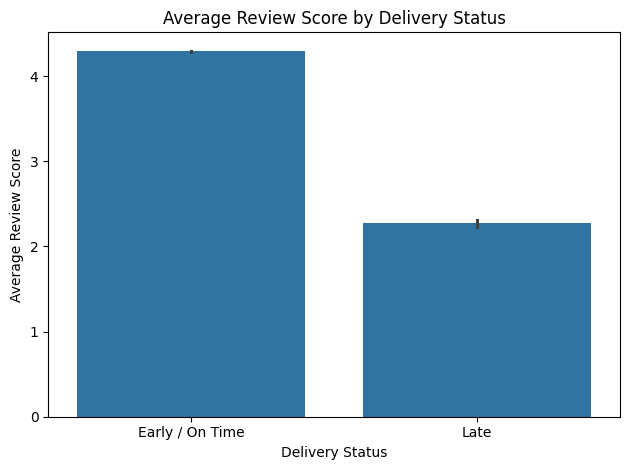

In [30]:
sns.barplot(
    data=delivery_reviews,
    x="delivery_status",
    y="review_score"
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.tight_layout()
plt.show()

### Note:
The above bar chart establishes, Late delivery is strongly associated with lower review scores. But, does this relationship hold across different categories and regions, or does it matter how late an order is?

In [31]:
delivery_reviews["delay_group"] = pd.cut(
    delivery_reviews["delivery_delay_days"],
    bins=[-np.inf, 0, 3, 7, 14, 30, np.inf],
    labels=[
        "Early / On Time",
        "1-3 Days Late",
        "4-7 Days Late",
        "8-14 Days Late",
        "15-30 Days Late",
        "30+ Days Late"
    ]
)

delivery_reviews.groupby("delay_group", observed=False)["review_score"].agg(
    ["count", "mean"]
).reset_index()

,delay_group,count,mean
0,Early / On Time,89443,4.290589
1,1-3 Days Late,1852,3.291037
2,4-7 Days Late,1748,2.105549
3,8-14 Days Late,1446,1.671508
4,15-30 Days Late,1006,1.617793
5,30+ Days Late,329,2.056231


### Note:
There's a very sharp deterioration in satisfaction as lateness increases:

4.29 -> 3.29 -> 2.11 -> 1.67 -> 1.62

That's compelling evidence that delivery delay is strongly associated with customer dissatisfaction.

### Visualization of delay severity vs. review score

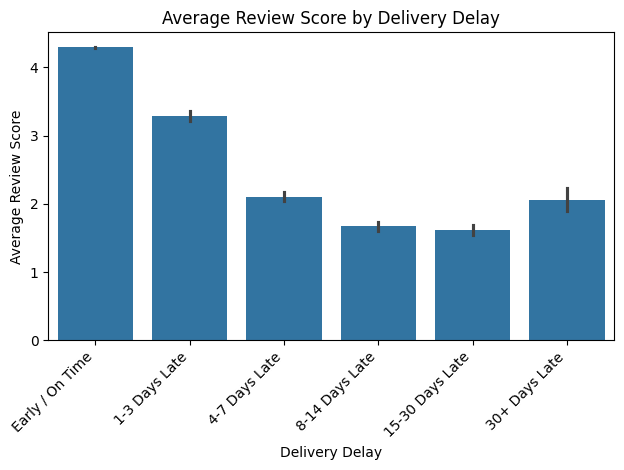

In [32]:
sns.barplot(
    data=delivery_reviews,
    x="delay_group",
    y="review_score"
)

plt.title("Average Review Score by Delivery Delay")
plt.xlabel("Delivery Delay")
plt.ylabel("Average Review Score")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

### Note:
**Customer satisfaction declines substantially as delivery delays increase.** Orders delivered early/on time averaged 4.29 stars, compared with 3.29 for orders 1–3 days late and approximately 1.6–2.1 for orders delayed by 4 days or more.

The small rebound for 30+ days late is worth noting, but because there are only 329 orders in that group, it shouldn't be treated as evidence that extreme delays improve satisfaction.

### Checking the overall relationship numerically

In [33]:
delivery_reviews[["delivery_delay_days","review_score"]].corr()

,delivery_delay_days,review_score
delivery_delay_days,1.000000,-0.267255
review_score,-0.267255,1.000000


### Note:
The correlation is only about -0.27, not -0.8 or -0.9.

It tells us that delivery delay is strongly associated with differences in average satisfaction between groups, but delivery delay alone does not explain all variation in review scores.

### Checking how many items orders contain

This is an important check before we connect product categories to our order-level review data.

In [34]:
items_per_order = items.groupby("order_id").size()

print("Average items per order:", items_per_order.mean())
print("Maximum items in one order:", items_per_order.max())

print("\nOrders with more than one item:")
print((items_per_order > 1).sum())

Average items per order: 1.1417306873695092
Maximum items in one order: 21

Orders with more than one item:
9803


### Note:
So one cannot simply merge `items` with `delivery_reviews` and assume one row = one order. Orders with multiple products would appear multiple times leading to duplicate rows.

It is optimal to retain one row per order. One approach is to assign each order a primary product category, using the category of its highest-priced item. This gives us one representative category per order without artificially duplicating orders.

### Inspecting the items data set

In [35]:
items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

### inspecting Products Dataset, before connecting it to items

In [36]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

### Note:
Because 9,803 orders contain multiple items, an order can technically belong to multiple product categories.

Before deciding how to categorize an order, let’s first check how many orders contain items from multiple categories. This will help us understand whether using the highest-priced item’s category is a small simplification or could meaningfully affect the results.

In [37]:
items_with_category = items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

categories_per_order = (
    items_with_category
    .groupby("order_id")["product_category_name"]
    .nunique()
)

print("Orders with multiple product categories:", (categories_per_order > 1).sum())

print("Maximum categories in one order:", categories_per_order.max())

Orders with multiple product categories: 786
Maximum categories in one order: 3


Only 786 orders contain products from more than one category, and the maximum is 3 categories. So for the vast majority of orders, assigning a representative category won't be a major issue.

### Identifying the highest-priced item in each order

For every order:

1. sort its items from highest price to lowest price;
2. keep the first item;
3. therefore get one representative product/category per order.

In [38]:
main_item = (
    items_with_category
    .sort_values(["order_id", "price"], ascending=[True, False])
    .drop_duplicates("order_id")
)

print("Number of orders:", len(main_item))

main_item[[
    "order_id",
    "product_id",
    "product_category_name",
    "price"
]].head()

Number of orders: 98666


,order_id,product_id,product_category_name,price
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.90
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,239.90
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,199.00
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,199.90


### Note:
expected orders: 99,441 orders, but main_item contains 98,666 orders.

So 775 orders in orders don't appear in items.

### Checking which orders are missing from items

In [39]:
missing_item_orders = orders[
    ~orders["order_id"].isin(main_item["order_id"])
]

print("Orders missing from items:", len(missing_item_orders))

print("\nOrder status of missing-item orders:")
print(missing_item_orders["order_status"].value_counts())

Orders missing from items: 775

Order status of missing-item orders:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


### Note:
None of the 96,470 delivered orders are in this missing-item group.
So, I can safely proceed with category analysis for the delivered-order dataset.

### Adding the representative category to our delivery dataset

Safely merging main_item with delivery_reviews

In [40]:
delivery_reviews = delivery_reviews.merge(
    main_item[["order_id", "product_category_name"]],
    on="order_id",
    how="left"
)

print("Rows:", len(delivery_reviews))
print("Unique orders:", delivery_reviews["order_id"].nunique())
print("Missing categories:", delivery_reviews["product_category_name"].isna().sum())

Rows: 95824
Unique orders: 95824
Missing categories: 0


This check is important because it confirms that the merge didn't duplicate orders and that every order in our analysis has a category.

### Comparing delivery impact across categories

In [41]:
category_summary = (
    delivery_reviews
    .groupby("product_category_name")
    .agg(
        orders=("order_id", "count"),
        average_review=("review_score", "mean"),
        average_delay=("delivery_delay_days", "mean"),
        late_orders=("delivery_status", lambda x: (x == "Late").sum())
    )
    .reset_index()
)

category_summary["late_rate"] = (
    category_summary["late_orders"] / category_summary["orders"] * 100
)

category_summary.sort_values("orders", ascending=False).head(10)

,product_category_name,orders,average_review,average_delay,late_orders,late_rate
14,cama_mesa_banho,9090,4.008196,-11.395600,666,7.326733
12,beleza_saude,8567,4.232851,-12.002101,633,7.388818
33,esporte_lazer,7448,4.235097,-11.851235,486,6.525242
45,informatica_acessorios,6480,4.083179,-12.390895,407,6.280864
55,moveis_decoracao,6142,4.079046,-12.295344,439,7.147509
73,utilidades_domesticas,5646,4.205101,-12.071909,300,5.313496
67,relogios_presentes,5436,4.122701,-11.833517,395,7.266372
71,telefonia,4049,4.059274,-11.237590,287,7.088170
9,automotivo,3774,4.153683,-11.259141,273,7.233704
13,brinquedos,3757,4.240484,-12.155177,232,6.175140


### Comparing late vs. early/on-time reviews within each category

In [42]:
category_delivery_review = (
    delivery_reviews
    .groupby(["product_category_name", "delivery_status"])
    .agg(
        orders=("order_id", "count"),
        average_review=("review_score", "mean")
    )
    .reset_index()
)

category_delivery_review.head(10)

,product_category_name,delivery_status,orders,average_review
0,Unknown,Early / On Time,1253,4.187949
1,Unknown,Late,96,2.114583
2,agro_industria_e_comercio,Early / On Time,170,4.205882
3,agro_industria_e_comercio,Late,7,1.714286
4,alimentos,Early / On Time,402,4.467662
5,alimentos,Late,30,2.566667
6,alimentos_bebidas,Early / On Time,211,4.523697
7,alimentos_bebidas,Late,8,2.500000
8,artes,Early / On Time,179,4.201117
9,artes,Late,12,2.500000


This confirms something important: the delivery effect appears within individual categories too, not just at the overall marketplace level.

### Calculating the delivery impact by category

Instead of looking at the two rows separately, let's calculate the difference:

`Early/on-time average review − Late average review`

In [43]:
category_impact = (
    delivery_reviews
    .groupby(["product_category_name", "delivery_status"])["review_score"]
    .mean()
    .unstack()
)

category_impact["review_drop"] = (
    category_impact["Early / On Time"]
    - category_impact["Late"]
)

category_impact = category_impact.reset_index()

category_impact.head(10)

delivery_status,product_category_name,Early / On Time,Late,review_drop
0,Unknown,4.187949,2.114583,2.073366
1,agro_industria_e_comercio,4.205882,1.714286,2.491597
2,alimentos,4.467662,2.566667,1.900995
3,alimentos_bebidas,4.523697,2.500000,2.023697
4,artes,4.201117,2.500000,1.701117
5,artes_e_artesanato,4.476190,1.000000,3.476190
6,artigos_de_festas,4.081081,NaN,NaN
7,artigos_de_natal,4.221239,2.666667,1.554572
8,audio,4.127907,1.725000,2.402907
9,automotivo,4.297344,2.311355,1.985988


### Note:
* But `artigos_de_festas` has `NaN` because there were **no late orders** in that category. That's not a missing-data error—it means there was nothing to compare.

* More importantly, some categories may have only a handful of late orders. A category with 3 late orders averaging 1.0 shouldn't be treated as stronger evidence than a category with 500 late orders averaging 2.0.

* So let's introduce a minimum sample size.

### Identifying categories with enough late orders

it requires at least 30 late orders before ranking categories by delivery impact.

In [44]:
category_late_counts = (
    delivery_reviews[delivery_reviews["delivery_status"] == "Late"]
    .groupby("product_category_name")
    .size()
    .reset_index(name="late_orders")
)

category_impact = category_impact.merge(
    category_late_counts,
    on="product_category_name",
    how="left"
)

category_impact_filtered = (
    category_impact[
        category_impact["late_orders"] >= 30
    ]
    .sort_values("review_drop", ascending=False)
)

category_impact_filtered.head(10)

,product_category_name,Early / On Time,Late,review_drop,late_orders
46,instrumentos_musicais,4.435252,1.913043,2.522208,46.0
8,audio,4.127907,1.725000,2.402907,40.0
13,brinquedos,4.379007,2.135776,2.243231,232.0
10,bebes,4.298889,2.073394,2.225495,218.0
33,esporte_lazer,4.379489,2.166667,2.212822,486.0
34,fashion_bolsas_e_acessorios,4.363183,2.190000,2.173183,100.0
22,construcao_ferramentas_construcao,4.305097,2.173077,2.132021,52.0
60,papelaria,4.445324,2.315068,2.130255,146.0
64,pet_shop,4.380893,2.253012,2.127880,83.0
63,perfumaria,4.406261,2.290000,2.116261,200.0


### Note:
* There's an important distinction that can be drawn from the table above:

1. `instrumentos_musicais` has the largest drop, but only 46 late orders.

2. `esporte_lazer`, on the other hand, has a slightly smaller drop (2.21) but 486 late orders.

* The negative association between late delivery and review scores appears across multiple categories, rather than being isolated to one category. Some categories show particularly large gaps, although the magnitude should be interpreted alongside the number of late orders.

Established Interpretations with Evidence:

* Overall: delivery delay <--> lower reviews
* By severity: more delay generally <--> lower reviews
* By category: the relationship appears across multiple categories

Now we need to check **regions**

### Inspecting customer geographic columns

In [45]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

I'll use `customer_state` as our **regional variable**. That's preferable to city because it gives us enough observations in each group while still showing geographic differences.

### Connecting customer_state to our analysis dataset

In [46]:
delivery_reviews = delivery_reviews.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

print("Rows:", len(delivery_reviews))
print("Unique orders:", delivery_reviews["order_id"].nunique())
print("Missing customer states:", delivery_reviews["customer_state"].isna().sum())

Rows: 95824
Unique orders: 95824
Missing customer states: 0


### State-level delivery performance

In [47]:
state_summary = (
    delivery_reviews
    .groupby("customer_state")
    .agg(
        orders=("order_id", "count"),
        average_review=("review_score", "mean"),
        average_delay=("delivery_delay_days", "mean"),
        late_orders=("delivery_status", lambda x: (x == "Late").sum())
    )
    .reset_index()
)

state_summary["late_rate"] = (
    state_summary["late_orders"] / state_summary["orders"] * 100
)

state_summary.sort_values("orders", ascending=False)

,customer_state,orders,average_review,average_delay,late_orders,late_rate
25,SP,40266,4.246519,-11.094298,1786,4.435504
18,RJ,12211,3.965141,-11.820490,1456,11.923675
10,MG,11285,4.192468,-13.265485,505,4.474967
22,RS,5326,4.185599,-13.920954,321,6.027037
17,PR,4900,4.239592,-13.345102,194,3.959184
23,SC,3519,4.133276,-11.570332,284,8.070475
4,BA,3229,3.930009,-10.896562,384,11.892227
6,DF,2070,4.133816,-12.036232,118,5.700483
7,ES,1969,4.079736,-10.682580,205,10.411376
8,GO,1946,4.104317,-12.246146,124,6.372045


### Note:
There is substantial variation in late-delivery rates across states:

* SP: 4.44% late, average review 4.25
* RJ: 11.92% late, average review 3.97
* BA: 11.89% late, average review 3.93
* CE: 13.67% late, average review 3.94
* MA: 17.13% late, average review 3.83
* AL: 20.81% late, average review 3.85

The states with relatively high late-delivery rates often also have lower average review scores.

### Testing the relationship between state late rate and state review score

In [48]:
state_summary[ ["late_rate", "average_review"] ].corr()

,late_rate,average_review
late_rate,1.000000,-0.880693
average_review,-0.880693,1.000000


### Note:
At the state level, **late-delivery rate** is strongly **negatively** associated with average **customer review scores** (r = -0.881).

### Note:
Repeating the correlation using only states with at least 500 orders. To avoid conclusions driven by very small groups.

In [49]:
state_summary_filtered = state_summary[
    state_summary["orders"] >= 500
]

print("Number of states:", len(state_summary_filtered))

print(
    state_summary_filtered[
        ["customer_state", "orders", "late_rate", "average_review"]
    ].sort_values("late_rate", ascending=False)
)

print("\nCorrelation:")
print(
    state_summary_filtered[
        ["late_rate", "average_review"]
    ].corr()
)

Number of states: 17
   customer_state  orders  late_rate  average_review
9              MA     712  17.134831        3.833567
5              CE    1273  13.668500        3.941870
18             RJ   12211  11.923675        3.965141
4              BA    3229  11.892227        3.930009
13             PA     933  10.718114        3.909968
7              ES    1969  10.411376        4.079736
14             PB     512  10.156250        4.076172
11             MS     699   9.728183        4.160229
15             PE    1579   9.436352        4.082964
23             SC    3519   8.070475        4.133276
8              GO    1946   6.372045        4.104317
22             RS    5326   6.027037        4.185599
12             MT     879   5.802048        4.146189
6              DF    2070   5.700483        4.133816
10             MG   11285   4.474967        4.192468
25             SP   40266   4.435504        4.246519
17             PR    4900   3.959184        4.239592

Correlation:
           

### Interesting Insight
Among the 17 Brazilian states with at least 500 reviewed delivered orders, states with higher late-delivery rates tend to have substantially lower average review scores (r = -0.912).

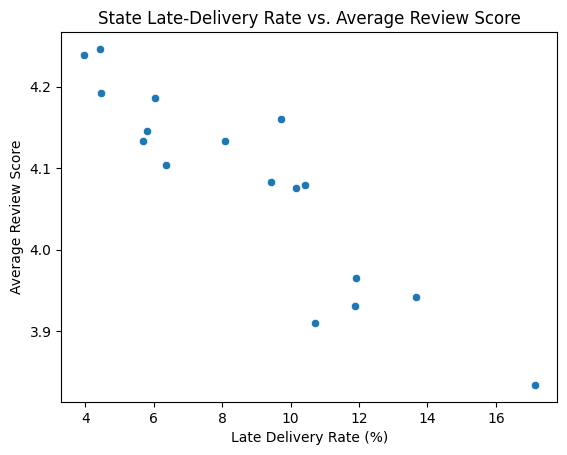

In [50]:
sns.scatterplot(
    data=state_summary_filtered,
    x="late_rate",
    y="average_review"
)

plt.title("State Late-Delivery Rate vs. Average Review Score")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Average Review Score")
plt.show()

### Note:
States with higher late-delivery rates tend to have lower average customer review scores, indicating a strong negative association between delivery performance and customer satisfaction.

# Business Question 2
## Seller & Geographic Patterns

### Q2.  Sellers and customers are not evenly distributed across Brazil. How does this geographic pattern relate to delivery performance, freight cost, or customer satisfaction?


In [51]:
delivery_reviews = delivery_reviews.merge(
    items[["order_id", "seller_id"]],
    on="order_id",
    how="left"
)

delivery_reviews = delivery_reviews.merge(
    sellers[["seller_id", "seller_state"]],
    on="seller_id",
    how="left"
)

print("Rows:", len(delivery_reviews))
print("Unique orders:", delivery_reviews["order_id"].nunique())
print("Missing seller states:", delivery_reviews["seller_state"].isna().sum())

Rows: 109362
Unique orders: 95824
Missing seller states: 0


### Note:
Rows not equal to Unique Orders, means our merge introduced duplicate rows. This happened because we merged the items table directly, and an order can contain multiple items (and therefore potentially multiple sellers).

we already created `main_item`, where we selected one representative item per order. We'll use its `seller_id` rather than merging the entire `items` table.

In [52]:
delivery_reviews = delivered_orders.merge(
    review_summary,
    on="order_id",
    how="inner"
)

delivery_reviews = delivery_reviews.merge(
    main_item[[
        "order_id",
        "product_category_name",
        "seller_id"
    ]],
    on="order_id",
    how="left"
)

delivery_reviews = delivery_reviews.merge(
    customers[[
        "customer_id",
        "customer_state"
    ]],
    on="customer_id",
    how="left"
)

delivery_reviews = delivery_reviews.merge(
    sellers[[
        "seller_id",
        "seller_state"
    ]],
    on="seller_id",
    how="left"
)

print("Rows:", len(delivery_reviews))
print("Unique orders:", delivery_reviews["order_id"].nunique())
print("Missing seller states:", delivery_reviews["seller_state"].isna().sum())

Rows: 95824
Unique orders: 95824
Missing seller states: 0


### Same-state vs different-state orders
Are orders more likely to be late when the seller and customer are in different states?

In [53]:
# creating a new column that identifies whether the seller and customer are in the same state
delivery_reviews["same_state"] = np.where(
    delivery_reviews["customer_state"] == delivery_reviews["seller_state"],
    "Same State",
    "Different State"
)
delivery_reviews["same_state"].value_counts().reset_index()

,same_state,count
0,Different State,61347
1,Same State,34477


### Note:
61,347 orders (64.0%) -> Different State

34,477 orders (36.0%) -> Same State

So most orders involve a seller and customer in different states.

### Comparing delivery and reviews

In [54]:
geography_summary = (
    delivery_reviews
    .groupby("same_state")
    .agg(
        orders=("order_id", "count"),
        average_delay=("delivery_delay_days", "mean"),
        late_orders=("delivery_status", lambda x: (x == "Late").sum()), # Number of late orders
        average_review=("review_score", "mean")
    )
    .reset_index()
)

# Above code takes all delivery-review orders, split them into Same State and Different State groups,
# and for each group calculate the number of orders, average delivery delay, number of late orders, and average review score.
# Then turn the grouping label back into a normal column and store the result in geography_summary Dataframe.

geography_summary["late_rate"] = (
    geography_summary["late_orders"]
    / geography_summary["orders"]
    * 100
)

geography_summary

,same_state,orders,average_delay,late_orders,average_review,late_rate
0,Different State,61347,-12.792736,4843,4.095511,7.894437
1,Same State,34477,-10.347826,1538,4.264070,4.460945


### Interesting Insight
Different-state orders have a substantially higher late-delivery rate:

* Different state: 7.89%
* Same state: 4.46%

That's a difference of about **3.43 percentage points**.

But `average_delay` in different state and same state remain negative, meaning both groups, on average, were delivered before the estimated date.

For now, Different-state orders have a higher probability of being late, despite both groups being delivered earlier than their estimated dates on average.

**This result doesn't prove that geographic distance itself causes delays.**
Because "different state" is only a rough geographic measure. A seller and customer could be in **neighboring states** or **extremely far apart**.

### Creating a Dataframe which contains seller-to-customer state routes

In [55]:
route_summary = (
    delivery_reviews
    .groupby(["seller_state", "customer_state"])
    .agg(
        orders=("order_id", "count"),
        late_orders=("delivery_status", lambda x: (x == "Late").sum()),
        average_review=("review_score", "mean")
    )
    .reset_index()
)

route_summary["late_rate"] = (
    route_summary["late_orders"]
    / route_summary["orders"]
    * 100
)

route_summary.sort_values("orders", ascending=False).head(5)

,seller_state,customer_state,orders,late_orders,average_review,late_rate
408,SP,SP,30537,1404,4.248300,4.597701
401,SP,RJ,8064,1125,3.887876,13.950893
393,SP,MG,7391,383,4.148491,5.181978
405,SP,RS,3581,236,4.124686,6.590338
400,SP,PR,3104,135,4.189594,4.349227


### Interestin Insight:
SP -> RJ is not just a high-volume route; it also has noticeably worse delivery performance (`late_rate = 13.95`) and satisfaction(`avg_review = 3.89`).

In [56]:
print(f'Average No. of Orders:{round(route_summary['orders'].mean(),2)}')

Average No. of Orders:233.72


### Keeping routes with at least 200 orders for a clearer picture

In [57]:
route_summary_filtered = route_summary[
    route_summary["orders"] >= 200
].copy()

print("Number of routes:", len(route_summary_filtered))

route_summary_filtered.sort_values(
    "late_rate",
    ascending=False
).head(10)

Number of routes: 48


,seller_state,customer_state,orders,late_orders,average_review,late_rate
384,SP,AL,253,59,3.719368,23.320158
392,SP,MA,488,91,3.712090,18.647541
407,SP,SE,208,34,3.817308,16.346154
399,SP,PI,325,53,3.960000,16.307692
401,SP,RJ,8064,1125,3.887876,13.950893
388,SP,CE,964,131,3.964212,13.589212
387,SP,BA,2291,291,3.871235,12.701877
394,SP,MS,476,59,4.088235,12.394958
390,SP,ES,1444,174,4.052632,12.049861
269,PR,RJ,957,112,3.889237,11.703239


### Interesting Insight:
Several high-volume routes originating from SP show elevated late-delivery rates, particularly routes to northeastern states such as AL, MA, SE, PI, CE and BA.

### Creating order-level freight summary
* The `table` has `freight_value` at the item level. Since an order can contain multiple items, we first need to add the freight costs together so that we have one freight value per order.
* I am doing this because `delivery_reviews` dataset is also one row per order. That keeps the analysis at the same level and prevents duplicate rows.

In [58]:
order_freight = (
    items
    .groupby("order_id")["freight_value"]
    .sum()
    .reset_index()
)

order_freight.head()

,order_id,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,13.29
1,00018f77f2f0320c557190d7a144bdd3,19.93
2,000229ec398224ef6ca0657da4fc703e,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,18.14


### Verifying the freight table

In [59]:
print("Total rows:", len(order_freight))
print("Unique orders:", order_freight["order_id"].nunique())
print("Missing freight values:", order_freight["freight_value"].isna().sum())

Total rows: 98666
Unique orders: 98666
Missing freight values: 0


### Adding freight to our analysis dataset
delivery_reviews + order_freight --> delivery_reviews with freight_value

In [60]:
delivery_reviews = delivery_reviews.merge(
    order_freight,
    on="order_id",
    how="left"
)

print("Rows:", len(delivery_reviews))
print("Unique orders:", delivery_reviews["order_id"].nunique()) # important validation --> Rows = Unique orders = 95,824
print("Missing freight values:", delivery_reviews["freight_value"].isna().sum())

Rows: 95824
Unique orders: 95824
Missing freight values: 0


### Average freight cost by geographic pattern
Do different-state orders tend to have higher freight costs than same-state orders?

In [61]:
delivery_reviews.groupby("same_state")["freight_value"].mean().reset_index()

,same_state,freight_value
0,Different State,26.884968
1,Same State,15.428193


### Note:
* **Different-state** orders have an average freight value about **11.46 higher** than **same-state orders**, or roughly 74% higher.
* Cross-state fulfillment is associated with higher freight costs, higher late-delivery rates, and lower customer satisfaction.

### Freight cost vs review score

In [62]:
delivery_reviews[ ["freight_value", "review_score"] ].corr()

,freight_value,review_score
freight_value,1.000000,-0.089959
review_score,-0.089959,1.000000


### Note:
1. A very weak negative(r = -0.09) relationship between freight cost and review score.
2. freight cost by itself does not appear to be a major explanation for differences in review scores.
3. Delivery delay vs review score: r = -0.267. So, delivery delay has a noticeably stronger relationship with reviews than freight value does.

### Visualization of Freight Cost by geographic pattern

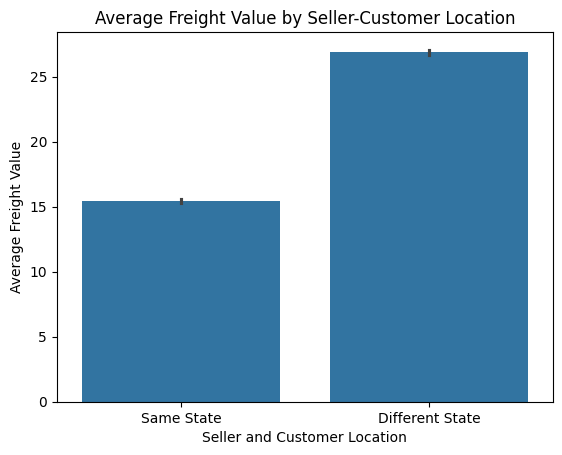

In [63]:
sns.barplot(
    data=delivery_reviews,
    x="same_state",
    y="freight_value"
)

plt.title("Average Freight Value by Seller-Customer Location")
plt.xlabel("Seller and Customer Location")
plt.ylabel("Average Freight Value")
plt.show()

### Useful Findings:
1. Geography
* Different-state orders have a higher late rate: 7.89% vs 4.46%.
2. Freight
* Different-state orders have much higher average freight cost: 26.88 vs 15.43.
3. Customer satisfaction
* Different-state orders have lower reviews: 4.10 vs 4.26.
* Freight cost vs review correlation is only -0.090, so freight cost alone doesn't explain much of the review variation.

### Conclusion to Q2:
Cross-state fulfillment is associated with higher freight costs and higher late-delivery rates, while also showing lower average review scores. However, freight cost alone has only a weak relationship with review scores (r = -0.090), suggesting that delivery performance is a more important indicator of customer satisfaction than freight cost itself.

# Business Question 3
## Product Category Performance

Q3. Which product categories generate the most orders/revenue, and how do their prices and review scores compare with the platform average?

Workflow:

Volume -> Revenue -> Average Price -> Customer Satisfaction

### Note:
Before I jump into the analysis, I decided to translate category names from portugese to english, for my better understanding.

In [64]:
print(categories.columns)
categories.head()

Index(['product_category_name', 'product_category_name_english'], dtype='object')


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [65]:
items_with_category = items_with_category.merge(
    categories,
    on="product_category_name",
    how="left"
)

print("Rows:", len(items_with_category))
print(
    "Missing English categories:",
    items_with_category["product_category_name_english"].isna().sum()
)

items_with_category[
    ["product_category_name", "product_category_name_english"]
].head(10)

Rows: 112650
Missing English categories: 1627


,product_category_name,product_category_name_english
0,cool_stuff,cool_stuff
1,pet_shop,pet_shop
2,moveis_decoracao,furniture_decor
3,perfumaria,perfumery
4,ferramentas_jardim,garden_tools
5,utilidades_domesticas,housewares
6,telefonia,telephony
7,ferramentas_jardim,garden_tools
8,beleza_saude,health_beauty
9,livros_tecnicos,books_technical


### Investigating the missing 1627 translations

In [66]:
items_with_category[ items_with_category["product_category_name_english"].isna() ]["product_category_name"].value_counts().reset_index()

,product_category_name,count
0,Unknown,1603
1,portateis_cozinha_e_preparadores_de_alimentos,15
2,pc_gamer,9


### Filling the missing category translations
only 24 actual products belong to those two untranslated categories. So, I chose the following approach:
* Keep `Unknown` as `Unknown`
* Manually translate the two missing categories into readable English, because the provided translation file did not contain them.

In [67]:
items_with_category["product_category_name_english"] = (
    items_with_category["product_category_name_english"]
    .fillna(items_with_category["product_category_name"])
)

items_with_category["product_category_name_english"] = (
    items_with_category["product_category_name_english"]
    .replace({
        "portateis_cozinha_e_preparadores_de_alimentos":
            "kitchen_appliances",
        "pc_gamer":
            "gaming_pc"
    })
)

print(
    "Missing English categories:",
    items_with_category["product_category_name_english"].isna().sum()
)

Missing English categories: 0


### Updating the `main-item` dataset with English categories

In [68]:
main_item = (
    items_with_category
    .sort_values(["order_id", "price"], ascending=[True, False])
    .drop_duplicates("order_id")
)

print("Rows:", len(main_item))
print("Unique orders:", main_item["order_id"].nunique())

main_item[
    [
        "order_id",
        "product_category_name",
        "product_category_name_english",
        "price"
    ]
].head()

Rows: 98666
Unique orders: 98666


,order_id,product_category_name,product_category_name_english,price
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,cool_stuff,58.90
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,pet_shop,239.90
2,000229ec398224ef6ca0657da4fc703e,moveis_decoracao,furniture_decor,199.00
3,00024acbcdf0a6daa1e931b038114c75,perfumaria,perfumery,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,ferramentas_jardim,garden_tools,199.90


### Category Order Volume
how many items belong to each product category?

In [69]:
category_volume = (
    items_with_category
    .groupby("product_category_name_english")
    .size()
    .reset_index(name="item_count")
)

category_volume = category_volume.sort_values(
    "item_count",
    ascending=False
)

category_volume.head(10)

,product_category_name_english,item_count
8,bed_bath_table,11115
45,health_beauty,9670
68,sports_leisure,8641
40,furniture_decor,8334
16,computers_accessories,7827
51,housewares,6964
73,watches_gifts,5991
71,telephony,4545
44,garden_tools,4347
6,auto,4235


### Note:
Bed, Bath & Table has the highest item volume, with 11,115 items.

### Category Sales Value (Revenue)

In [70]:
category_revenue = (
    items_with_category
    .groupby("product_category_name_english")["price"]
    .sum()
    .reset_index(name="revenue")
)

category_revenue = category_revenue.sort_values(
    "revenue",
    ascending=False
)

category_revenue.head(10)

,product_category_name_english,revenue
45,health_beauty,1258681.34
73,watches_gifts,1205005.68
8,bed_bath_table,1036988.68
68,sports_leisure,988048.97
16,computers_accessories,911954.32
40,furniture_decor,729762.49
21,cool_stuff,635290.85
51,housewares,632248.66
6,auto,592720.11
44,garden_tools,485256.46


### Interesting Insight:
* **Watches & Gifts**: it is only `7th in item volume` but `2nd in revenue`, suggesting a considerably **higher average selling price**.
* **Health & Beauty** is strong on both volume and revenue.

### Investigating Average Product Price

In [71]:
category_price = (
    items_with_category
    .groupby("product_category_name_english")["price"]
    .mean()
    .reset_index(name="average_price")
)

category_price = category_price.sort_values(
    "average_price",
    ascending=False
)

category_price.head(10)

,product_category_name_english,average_price
15,computers,1098.340542
67,small_appliances_home_oven_and_coffee,624.285658
47,home_appliances_2,476.124958
1,agro_industry_and_commerce,342.124858
59,musical_instruments,281.616000
66,small_appliances,280.778468
53,kitchen_appliances,264.568667
35,fixed_telephony,225.693182
20,construction_tools_safety,208.992371
73,watches_gifts,201.135984


### Note:
**Watches & Gifts** ranks 2nd in revenue despite being only 7th in item volume, because its average item price (201.14) is much higher than the high-volume categories such as Bed, Bath & Table.

### Investigating Customer Satisfaction

In [72]:
category_reviews = (
    items_with_category
    .merge(
        review_summary,
        on="order_id",
        how="left"
    )
    .groupby("product_category_name_english")["review_score"]
    .mean()
    .reset_index(name="average_review")
)

category_reviews = category_reviews.sort_values(
    "average_review",
    ascending=False
)

category_reviews.head(10)

,product_category_name_english,average_review
12,cds_dvds_musicals,4.642857
30,fashion_childrens_clothes,4.500000
9,books_general_interest,4.446266
23,costruction_tools_tools,4.444444
36,flowers,4.419355
10,books_imported,4.400000
11,books_technical,4.363636
56,luggage_accessories,4.315257
38,food_drink,4.312274
67,small_appliances_home_oven_and_coffee,4.302632


### Limitations in the above approach:
These are high scores, but there's an important issue: some of these categories may have relatively few orders. For example, CDs/DVDs/Musicals could have a high average simply because its sample is small. It should not yet be categorized as the "best-performing categories." Before proceeding further, it needs to be compared against the platform average and account for category volume.

### Categories vs Marketplace Benchmark
Before comparing categories, let's establish our benchmark.

In [73]:
overall_review_average = review_summary["review_score"].mean()

print("Overall platform review average:", round(overall_review_average,2))

Overall platform review average: 4.09


### Note:

**4.09** is our platform-wide review benchmark.

That means I can now classify categories as:

* Above 4.09 -> performing above the platform average in customer satisfaction.
* Below 4.09 -> performing below the platform average.

But we should only compare categories with a reasonable number of orders, otherwise a category with 5–10 reviews could look artificially excellent or poor.

### Overall Category Performance

In [74]:
category_reviews_count = (
    items_with_category
    .merge(
        review_summary,
        on="order_id",
        how="left"
    )
    .groupby("product_category_name_english")
    .agg(
        orders=("order_id", "count"),
        average_review=("review_score", "mean")
    )
    .reset_index()
)

category_reviews_count = category_reviews_count[
    category_reviews_count["orders"] >= 200
].copy()

category_reviews_count["difference_from_average"] = (
    category_reviews_count["average_review"]
    - overall_review_average
)

category_reviews_count = category_reviews_count.sort_values(
    "difference_from_average",
    ascending=False
)

category_reviews_count.head(10)

,product_category_name_english,orders,average_review,difference_from_average
9,books_general_interest,553,4.446266,0.359473
11,books_technical,267,4.363636,0.276843
56,luggage_accessories,1092,4.315257,0.228464
38,food_drink,278,4.312274,0.225481
32,fashion_shoes,262,4.238372,0.151579
37,food,510,4.218182,0.131388
69,stationery,2517,4.195478,0.108685
63,pet_shop,1947,4.184306,0.097512
15,computers,203,4.175000,0.088207
46,home_appliances,771,4.166450,0.079656


### Find the lowest-rated categories


In [75]:
category_reviews_count.tail(10)

,product_category_name_english,orders,average_review,difference_from_average
3,art,209,3.937198,-0.149595
16,computers_accessories,7827,3.932601,-0.154193
40,furniture_decor,8334,3.907333,-0.179460
41,furniture_living_room,503,3.901606,-0.185187
8,bed_bath_table,11115,3.898334,-0.188460
0,Unknown,1603,3.839836,-0.246957
49,home_confort,434,3.833333,-0.253460
5,audio,364,3.831944,-0.254849
35,fixed_telephony,264,3.681992,-0.404801
60,office_furniture,1691,3.488968,-0.597825


### Interesting Insights:
Among categories with at least 200 orders:

1. Books — General Interest is the strongest: 4.45, about +0.36 above the platform average.
2. Books — Technical: 4.36, +0.28.
3. Luggage & Accessories: 4.32, +0.23.
4. Food & Drink: 4.31, +0.23.
* Stationery is particularly interesting because the result is based on 2,517 orders, yet it still scores above average at 4.20.
* Computers is also above average (4.18), despite having the highest average price from our previous analysis.
5. The weakest category is office furniture:
* 1,691 orders
* Average review: 3.49
* 0.60 points below the platform average of 4.09

**Bed, Bath & Table** is particularly interesting because it is #1 category by item volume (11,115) but has a below-average review score of 3.90.

### Building a clean order-level category review dataset

I will use our existing `main_item` DataFrame, where each order has one representative category (the highest-priced item).

In [76]:
category_order_reviews = main_item[
    ["order_id", "product_category_name_english"]
].merge(
    review_summary,
    on="order_id",
    how="inner"
)

category_order_reviews = (
    category_order_reviews
    .groupby("product_category_name_english")
    .agg(
        orders=("order_id", "count"),
        average_review=("review_score", "mean")
    )
    .reset_index()
)

category_order_reviews = category_order_reviews[
    category_order_reviews["orders"] >= 200
].copy()

category_order_reviews["difference_from_average"] = (
    category_order_reviews["average_review"]
    - overall_review_average
)

category_order_reviews.head()

,product_category_name_english,orders,average_review,difference_from_average
0,Unknown,1404,3.942664,-0.144130
2,air_conditioning,248,4.032258,-0.054535
5,audio,343,3.841108,-0.245686
6,auto,3860,4.097798,0.011005
7,baby,2813,4.055279,-0.031514


### Sorting Categories by satisfaction

In [77]:
category_order_reviews = category_order_reviews.sort_values(
    "difference_from_average",
    ascending=False
)

print("Top 10 categories:")
display(category_order_reviews.head(10))

print("\nBottom 10 categories:")
display(category_order_reviews.tail(10))

Top 10 categories:


,product_category_name_english,orders,average_review,difference_from_average
9,books_general_interest,505,4.469307,0.382514
11,books_technical,255,4.396078,0.309285
38,food_drink,224,4.386161,0.299367
56,luggage_accessories,1023,4.331378,0.244585
37,food,440,4.284091,0.197297
69,stationery,2275,4.255165,0.168371
63,pet_shop,1695,4.239528,0.152735
32,fashion_shoes,234,4.228632,0.141839
52,industry_commerce_and_business,231,4.216450,0.129657
62,perfumery,3133,4.209863,0.123069



Bottom 10 categories:


,product_category_name_english,orders,average_review,difference_from_average
40,furniture_decor,6280,4.029379,-0.057414
16,computers_accessories,6630,4.027979,-0.058815
71,telephony,4148,4.010125,-0.076668
50,home_construction,476,4.006303,-0.080491
8,bed_bath_table,9225,3.979133,-0.107661
0,Unknown,1404,3.942664,-0.144130
35,fixed_telephony,214,3.901869,-0.184924
49,home_confort,373,3.890080,-0.196713
5,audio,343,3.841108,-0.245686
60,office_furniture,1260,3.618651,-0.468143


### Note:
The **strongest** categories by customer satisfaction are:
1. Books — General Interest: 4.47, +0.38 above average, 505 orders
2. Books — Technical: 4.40, +0.31, 255 orders
3. Food & Drink: 4.39, +0.30, 224 orders
4. Luggage & Accessories: 4.33, +0.24, 1,023 orders
5. Stationery: 4.26, +0.17, 2,275 orders
6. Perfumery: 4.21, +0.12, 3,133 orders

The **weak** side is even more interesting

Office Furniture stands out:
1,260 orders -> 3.62 average review -> −0.47 vs platform average. That's a substantial gap and a large enough sample to take seriously.

### Combining all the category metrics before answering Q4

### Why?
From that combination, I can identify things such as:

* High volume + high revenue + good reviews -> strong overall category
* High volume + high revenue + poor reviews -> important improvement opportunity
* Low volume + high average price -> premium/niche category
* High volume + low revenue -> potentially low-priced/high-frequency category
* High revenue + below-average reviews -> commercially important but potentially problematic

In [78]:
category_analysis = (
    category_volume
    .merge(
        category_revenue,
        on="product_category_name_english",
        how="left"
    )
    .merge(
        category_price,
        on="product_category_name_english",
        how="left"
    )
    .merge(
        category_order_reviews[
            [
                "product_category_name_english",
                "orders",
                "average_review",
                "difference_from_average"
            ]
        ],
        on="product_category_name_english",
        how="left"
    )
)

category_analysis.head()

,product_category_name_english,item_count,revenue,average_price,orders,average_review,difference_from_average
0,bed_bath_table,11115,1036988.68,93.296327,9225.0,3.979133,-0.107661
1,health_beauty,9670,1258681.34,130.163531,8736.0,4.184219,0.097425
2,sports_leisure,8641,988048.97,114.344285,7632.0,4.174397,0.087604
3,furniture_decor,8334,729762.49,87.564494,6280.0,4.029379,-0.057414
4,computers_accessories,7827,911954.32,116.513903,6630.0,4.027979,-0.058815


### Interesting Insights:
* **Health & Beauty**: high volume (9,670), highest revenue among these five (1.26M in dataset currency), and above-average reviews (4.18).
* **Sports & Leisure**: high volume and strong revenue, with reviews also above average (4.17).
* **Bed, Bath & Table**: highest volume (11,115) but reviews are below average (3.98).
* **Furniture & Decor**: high volume but relatively lower revenue and slightly below-average reviews.
* **Computers & Accessories**: high volume, substantial revenue, but also slightly below average reviews.

### Investigating High-volume categories with below-average reviews

In [79]:
category_analysis[
    (category_analysis["item_count"] >= 3000) & # We're using 3,000+ items simply to focus on categories with substantial sales volume.
    (category_analysis["difference_from_average"] < 0)
].sort_values(
    "difference_from_average"
)

,product_category_name_english,item_count,revenue,average_price,orders,average_review,difference_from_average
0,bed_bath_table,11115,1036988.68,93.296327,9225.0,3.979133,-0.107661
7,telephony,4545,323667.53,71.213978,4148.0,4.010125,-0.076668
4,computers_accessories,7827,911954.32,116.513903,6630.0,4.027979,-0.058815
3,furniture_decor,8334,729762.49,87.564494,6280.0,4.029379,-0.057414
13,baby,3065,411764.89,134.344173,2813.0,4.055279,-0.031514
6,watches_gifts,5991,1205005.68,201.135984,5560.0,4.067086,-0.019707


### Interesting Insights:
The three strongest business opportunities stand out:

1. **Bed, Bath & Table**

* This is the biggest concern. It has the highest item volume among these categories (11,115) and over 1.0M in revenue, yet its review score is below average. High demand + below-average satisfaction makes this particularly worth investigating.

2. **Computers & Accessories**

* 7,827 items and ~912K revenue, but a 4.03 review score. This is another commercially important category where customer satisfaction is slightly weaker than the platform benchmark.

3. **Watches & Gifts**

* This one is interesting for a different reason: 5,991 items -> 1.205M revenue -> 201 average price, making it one of the strongest revenue categories, yet its review score is only 4.07, barely above/basically around the platform benchmark.

And notice something important: revenue and satisfaction aren't moving together perfectly. That's exactly why looking at only one metric would have given us an incomplete picture.

### Visualizing Top 10 categories by revenue

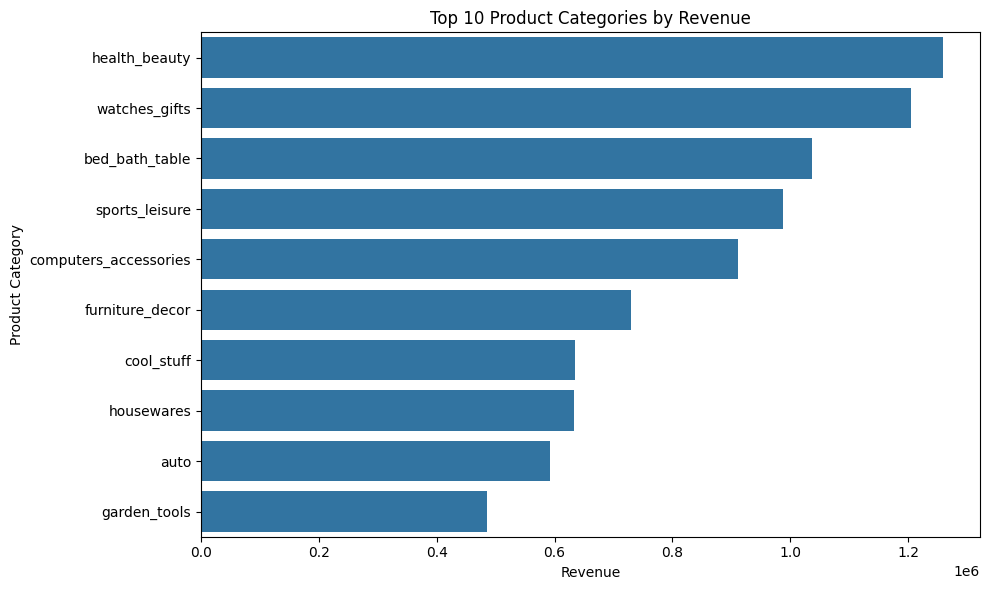

In [80]:
top_revenue_categories = category_analysis.sort_values(
    "revenue",
    ascending=False
).head(10)
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_revenue_categories,
    x="revenue",
    y="product_category_name_english"
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

Neaxt Question should be, Are the categories generating the most revenue also satisfying customers?

### Visualizing Satisfaction of the top revenue categories

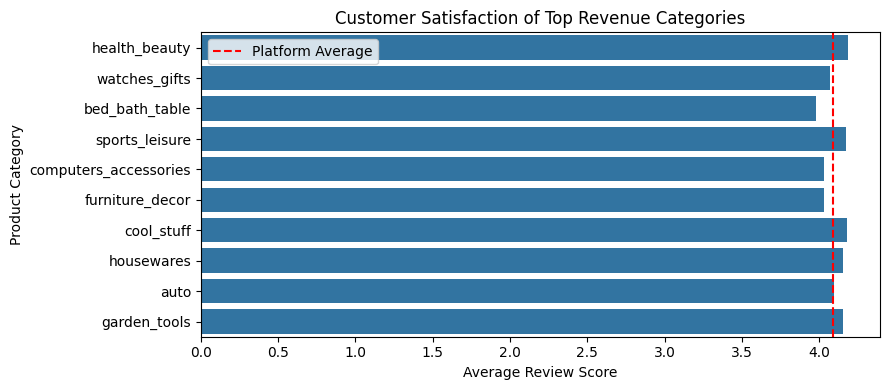

In [81]:
top_revenue_categories = category_analysis.sort_values(
    "revenue",
    ascending=False
).head(10)
plt.figure(figsize=(9,4))
sns.barplot(
    data=top_revenue_categories,
    x="average_review",
    y="product_category_name_english"
)

plt.axvline(
    overall_review_average,
    linestyle="--",
    label="Platform Average",
    color='red'
)
plt.title("Customer Satisfaction of Top Revenue Categories")
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")
plt.legend()
plt.tight_layout()
plt.show()

### Note:
* Bed, Bath & Table is the highest-volume category and a major revenue contributor, but its customer satisfaction is below the platform average.
* Health & Beauty and Sports & Leisure combine high revenue/volume with above-average customer satisfaction, making them stronger overall performers.

I've calculated category average prices, but haven't yet calculated the overall average item price. Without that benchmark, I can't properly say whether a category is high- or low-priced relative to the platform.

### Overall average product price


In [82]:
overall_average_price = items["price"].mean()

print("Overall average product price:", round(overall_average_price,2))

Overall average product price: 120.65


### Comparing category prices with the platform average

In [83]:
category_analysis["difference_from_average_price"] = (
    category_analysis["average_price"]
    - overall_average_price
)

category_analysis.sort_values(
    "difference_from_average_price",
    ascending=False
).head()

,product_category_name_english,item_count,revenue,average_price,orders,average_review,difference_from_average,difference_from_average_price
46,computers,203,222963.13,1098.340542,NaN,NaN,NaN,977.686803
55,small_appliances_home_oven_and_coffee,76,47445.71,624.285658,NaN,NaN,NaN,503.631919
42,home_appliances_2,238,113317.74,476.124958,232.0,4.133621,0.046827,355.471219
44,agro_industry_and_commerce,212,72530.47,342.124858,NaN,NaN,NaN,221.471119
24,musical_instruments,680,191498.88,281.616000,619.0,4.189015,0.102221,160.962261


### Why are some review columns `NaN`?

`category_analysis` contains review information only for categories with at least 200 reviewed orders, because I deliberately filtered small samples earlier. I shouldn't manufacture a satisfaction conclusion when the sample is too small.

### Numerical Insights:
1. Volume

* Bed, Bath & Table is the largest by item count: 11,115

2. Revenue

* Health & Beauty: 1.26M
* Watches & Gifts: 1.21M
* Bed, Bath & Table: 1.04M

3. Price

* Platform average: 120.65
* Computers: 1,098.34
* Watches & Gifts: 201.14
* Health & Beauty: 130.16
* Bed, Bath & Table: 93.30

4. Customer satisfaction

* Platform average: 4.09
* Strong examples: Books — General Interest 4.47, Luggage & Accessories 4.33, Stationery 4.26
* Major weak spot: Office Furniture 3.62
* High-volume concern: Bed, Bath & Table 3.98

### Conclusion to Q3:

Product category performance varied considerably across volume, revenue, pricing, and customer satisfaction.
* Health & Beauty and Sports & Leisure combined high sales volume and revenue with above-average review scores, indicating relatively strong overall performance.
* In contrast, Bed, Bath & Table generated the highest item volume and substantial revenue but had below-average satisfaction (3.98 vs 4.09), making it a key category for further investigation.
* Watches & Gifts generated the second-highest revenue despite lower volume, supported by a higher average selling price.
* Office Furniture had the lowest satisfaction among sufficiently sampled categories (3.62), suggesting a potential product or service quality issue despite its 1,260 reviewed orders.

### Limitations:
Category-level commercial metrics (item count, revenue and average price) were calculated at the item level. For customer satisfaction, one representative category per order was used, selecting the highest-priced item when an order contained multiple categories. This avoids counting a single order's review multiple times but may not fully represent satisfaction for multi-category orders.

# Business Question 4
## Payment Behavior

### Q4. How do payment methods and installment choices relate to order value, and do payment patterns appear to be associated with other aspects of the customer experience?

* Investigation pattern I followed: Payment type / installments -> order value -> customer experience

### Inspecting payment types

In [84]:
payments["payment_type"].value_counts().reset_index()

,payment_type,count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


### Checking payments per order

In [85]:
payments_per_order = payments.groupby("order_id").size()

print("Average payments per order:", round(payments_per_order.mean(),2))
print("Maximum payments for one order:", payments_per_order.max())
print("Orders with multiple payment records:", (payments_per_order > 1).sum())

Average payments per order: 1.04
Maximum payments for one order: 29
Orders with multiple payment records: 2961


### Note:
Most orders have only one payment record. But 2,961 orders have multiple payment records. One order has as many as 29 payment records, so simply treating every payment row as an order would be misleading.

For order value, we'll therefore aggregate `payment_value` by `order_id`.

### Checking multiple payment types per order

In [86]:
payment_types_per_order = (
    payments.groupby("order_id")["payment_type"]
    .nunique()
)

print(
    "Orders with multiple payment types:",
    (payment_types_per_order > 1).sum()
)

print(
    "Maximum different payment types in one order:",
    payment_types_per_order.max()
)

Orders with multiple payment types: 2246
Maximum different payment types in one order: 2


### Investigating Payment value by payment type

In [87]:
payment_summary = (
    payments
    .groupby("payment_type")
    .agg(
        payment_records=("order_id", "count"),
        total_value=("payment_value", "sum"),
        average_value=("payment_value", "mean")
    )
    .reset_index()
)

payment_summary = payment_summary.sort_values(
    "total_value",
    ascending=False
)

payment_summary

,payment_type,payment_records,total_value,average_value
1,credit_card,76795,12542084.19,163.319021
0,boleto,19784,2869361.27,145.034435
4,voucher,5775,379436.87,65.703354
2,debit_card,1529,217989.79,142.570170
3,not_defined,3,0.00,0.000000


### Note:
* Credit card dominates: 76,795 payment records and about 12.54M in total payment value.
* Boleto (Cash) is the second-largest method, with about 2.87M in total value.
* Voucher has a much lower average payment value (~65.70), which makes sense because voucher payments can be used alongside another payment method.
* `not_defined` has only 3 records, so we should exclude it from meaningful comparisons.
* Most importantly, `average_value` is the **average payment-record value**, not necessarily the average order value. Because 2,246 orders use multiple payment types, we shouldn't conclude that credit-card users have larger orders based on this table alone.

### calculating total payment value per order

In [88]:
order_payment_summary = (
    payments
    .groupby("order_id")
    .agg(
        order_value=("payment_value", "sum"),
        installments=("payment_installments", "max")
    )
    .reset_index()
)

print("Rows:", len(order_payment_summary))
print("Unique orders:", order_payment_summary["order_id"].nunique())

order_payment_summary.head()

Rows: 99440
Unique orders: 99440


,order_id,order_value,installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,3
2,000229ec398224ef6ca0657da4fc703e,216.87,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3


### Note:
* An order may have multiple payment records, so adding those payments together to get the true total payment value of each order. For installments, taking the maximum installment count recorded for that order.
* But by doing this, I've temporarily lost the payment type in this order-level dataset and need to bring that back carefully, because an order can have two different payment types.

### Investigating the unique payment types for each order

In [89]:
order_payment_type = (
    payments
    .groupby("order_id")["payment_type"]
    .agg(lambda x: ", ".join(sorted(x.unique())))
    .reset_index()
)

order_payment_type["payment_type"].value_counts().reset_index()

,payment_type,count
0,credit_card,74259
1,boleto,19784
2,"credit_card, voucher",2245
3,voucher,1621
4,debit_card,1527
5,not_defined,3
6,"credit_card, debit_card",1


* 2,246 orders used more than one payment type, overwhelmingly credit card + voucher.

### combining payment type with order value

I already created `order_payment_summary` which contains `order_id, order_value, installments`

In [90]:
payment_orders = order_payment_summary.merge(
    order_payment_type,
    on="order_id",
    how="inner"
)

payment_orders.head()

,order_id,order_value,installments,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


### verifing the merged dataset

In [91]:
print("Rows:", len(payment_orders))
print("Unique orders:", payment_orders["order_id"].nunique())
print("Missing payment types:", payment_orders["payment_type"].isna().sum())
print("Missing order values:", payment_orders["order_value"].isna().sum())

Rows: 99440
Unique orders: 99440
Missing payment types: 0
Missing order values: 0


### Step 1 of Objective 4: Order value by payment type

Do different payment methods tend to be associated with different order values?

### Calculating Average total order value for each payment type.

In [92]:
payment_value_analysis = (
    payment_orders
    .groupby("payment_type")["order_value"]
    .mean()
    .reset_index()
    .sort_values("order_value", ascending=False)
)

payment_value_analysis

,payment_type,order_value
1,credit_card,166.946479
2,"credit_card, debit_card",152.820000
3,"credit_card, voucher",150.876334
0,boleto,145.034435
4,debit_card,142.724158
6,voucher,114.387588
5,not_defined,0.000000


### Note:
Orders paid entirely by credit card had the highest average order value among the major payment groups, while voucher-only orders had the lowest.

But we cannot yet say that choosing credit card causes people to spend more. This is an association, and customer/order characteristics could explain the difference.

### Investigating distribution of installments.

In [93]:
payment_orders["installments"].value_counts().sort_index().reset_index()

,installments,count
0,0,2
1,1,48268
2,2,12363
3,3,10429
4,4,7070
5,5,5227
6,6,3908
7,7,1622
8,8,4251
9,9,644


### Observation:
* I could calculate average order value for every individual installment count. But the tail would become noisy because some installment counts have very few orders.

I think it makes more sense to create three meaningful groups:

* 1 installment → paid in full
* 2–6 installments → moderate installment usage
* 7+ installments → higher installment usage

This gives us sufficiently large groups and makes the eventual chart and explanation much easier.

### Creating installment groups

In [94]:
payment_orders["installment_group"] = pd.cut(
    payment_orders["installments"],
    bins=[-1, 1, 6, np.inf], # starting at -1 ensures that 0 installments are also considered as a part of analysis
    labels=[
        "1 Installment",
        "2-6 Installments",
        "7+ Installments"
    ]
)

payment_orders["installment_group"].value_counts().reset_index()

,installment_group,count
0,1 Installment,48270
1,2-6 Installments,38997
2,7+ Installments,12173


### checking do installment groups differ in order value?
Do customers who use more installments tend to place higher-value orders?

In [95]:
installment_value_analysis = (
    payment_orders
    .groupby("installment_group")["order_value"]
    .mean()
    .reset_index()
)

installment_value_analysis

/tmp/ipykernel_1723/1545562085.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("installment_group")["order_value"]


,installment_group,order_value
0,1 Installment,121.036364
1,2-6 Installments,155.453424
2,7+ Installments,337.158435


### Note:
Higher installment usage is strongly associated with higher order values.

### Adding review scores

In [96]:
payment_orders = payment_orders.merge(
    review_summary,
    on="order_id",
    how="left"
)

print("Rows:", len(payment_orders))
print("Unique orders:", payment_orders["order_id"].nunique())
print("Missing review scores:", payment_orders["review_score"].isna().sum())

Rows: 99440
Unique orders: 99440
Missing review scores: 768


### Note:
So 768 orders don't have a review record in review_summary.

That means:

* Should not delete these orders from payment_orders because they are still valid payment/order records.
* When analyzing customer satisfaction,I will simply use the orders that actually have a review score.
* The payment/order-value analysis can continue using all 99,440 orders.

### Payment method vs customer satisfaction

`not_defined` has only **3 orders** and `credit_card, debit_card` has only **1 order**, I don't want those tiny groups distorting the interpretation.

I decided to first calculate average review score and number of reviewed orders for each payment group.

In [97]:
payment_review_analysis = (
    payment_orders
    .dropna(subset=["review_score"])
    .groupby("payment_type")
    .agg(
        orders=("order_id", "count"),
        average_review=("review_score", "mean")
    )
    .reset_index()
    .sort_values("average_review", ascending=False)
)

payment_review_analysis = payment_review_analysis[
    (payment_review_analysis["payment_type"] != "not_defined")
    & (payment_review_analysis["payment_type"] != "credit_card, debit_card")
]

payment_review_analysis

,payment_type,orders,average_review
3,debit_card,1521,4.169954
1,credit_card,73683,4.088688
0,boleto,19636,4.087136
2,"credit_card, voucher",2227,4.070274
5,voucher,1602,3.945901


### Note:
* Credit card and boleto(cash) are almost identical (4.09 vs 4.09) despite being very different payment methods.
* Payment method doesn't appear to have a large relationship with satisfaction in this dataset, at least based on these averages.

### Visualizing payment type vs review score

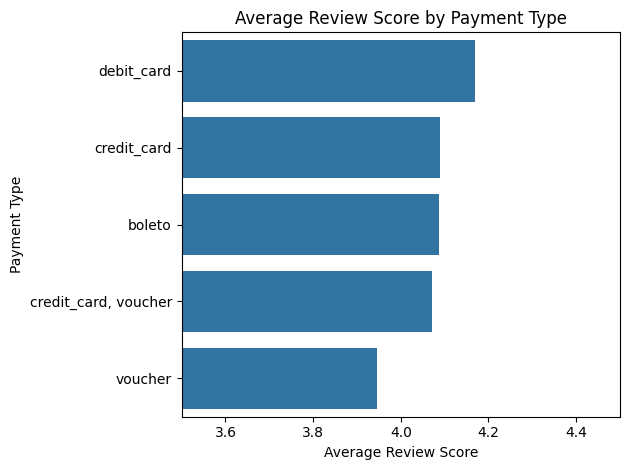

In [98]:
sns.barplot(
    data=payment_review_analysis,
    x="average_review",
    y="payment_type"
)

plt.xlabel("Average Review Score")
plt.ylabel("Payment Type")
plt.title("Average Review Score by Payment Type")
plt.xlim(3.5, 4.5) # scores are between 1 and 5, but all these averages are clustered around 4.
plt.tight_layout()
plt.show()

### Interesting Insights:
* The important takeaway is that the differences are modest when compared to delivery delays.
* At this point, I'd consider payment method a relatively weak indicator of customer satisfaction compared with delivery performance.
* However I didn't answer the question, ***does the number of installments relate to customer experience?***
* I've already discovered that installment count is strongly associated with order value(1 intsallment -> order value:121, 7+ installments -> order value:337.15). Now let's check whether it is also associated with review score.


### Investigating installments vs review score

In [99]:
installment_review_analysis = (
    payment_orders
    .dropna(subset=["review_score"])
    .groupby("installment_group")
    .agg(
        orders=("order_id", "count"),
        average_review=("review_score", "mean")
    )
    .reset_index()
)

installment_review_analysis

/tmp/ipykernel_1723/3992867523.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("installment_group")


,installment_group,orders,average_review
0,1 Installment,47928,4.118362
1,2-6 Installments,38688,4.075756
2,7+ Installments,12056,3.996972


### Correlation Matrix between No. of Installments and Average review score

In [100]:
payment_orders[["installments", "review_score"]].corr()

,installments,review_score
installments,1.000000,-0.031006
review_score,-0.031006,1.000000


### Note:
1. Although the installment groups showed:
- 1 installment -> 4.12 reviews
- 7+ installments -> 4.00 reviews
- The overall numerical relationship between installment count and review score is very weak(r = -0.031).
2. Compare this with delivery
* Delivery delay vs review score -> r = -0.267
* Installments vs review score -> r = -0.031

Payment behavior, particularly installment count, appears to be much more strongly associated with order value than with customer satisfaction.

### Visualizing installment group vs average order value

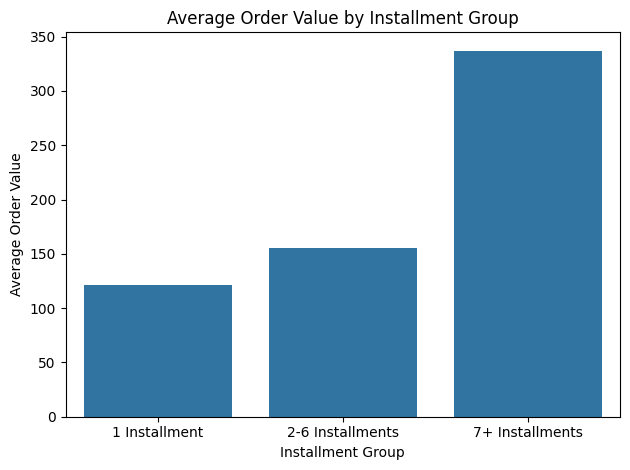

In [101]:
sns.barplot(
    data=installment_value_analysis,
    x="installment_group",
    y="order_value"
)

plt.xlabel("Installment Group")
plt.ylabel("Average Order Value")
plt.title("Average Order Value by Installment Group")
plt.tight_layout()
plt.show()

### Interseting insights to Q4.

1. **Payment method and order value**

* Credit-card-only orders had the highest average order value among the major payment groups:

  * Credit card -> 166.95

  * Boleto -> 145.03

  * Debit card -> 142.72

  * Voucher -> 114.39

  ***Mixed credit_card + voucher orders averaged R$150.88.***

2. **Installments and order value**

* This is the strongest relationship we found:

  * 1 installment -> 121.04

  * 2–6 installments -> 155.45

  * 7+ installments -> 337.16

  ***Higher installment usage is strongly associated with higher order value.***

3. **Payment behavior and customer satisfaction**

* The relationship with reviews is much weaker:

  * Payment methods ranged from 3.95 to 4.17 average review.
  * Installment groups ranged from 4.00 to 4.12.
  * Installments vs. review score correlation = -0.031, which is essentially negligible.

  Therefore, I ***would not*** present **payment method or installment count as a major driver of customer satisfaction.**

### Final Conclusion for Q4.
* Payment behavior was more strongly associated with order value than with customer satisfaction.
* Credit-card orders had the highest average order value among the major payment groups, while orders using 7+ installments had an average value of 337.16 compared with 121.04 for single-installment orders.
* However, installment count had almost no linear relationship with review scores (r = -0.031), and differences in satisfaction across payment methods were relatively small.
* This suggests that payment behavior is more relevant for understanding purchase value than customer experience.

# Business Question 5
## Root Cause Analysis

### Q5. Identify the primary and secondary contributors to low customer reviews, without claiming that one factor is the single root cause.

I've already discovered several potential contributors:

* Delivery lateness --> strong relationship with reviews
* Customer/seller geography --> related to late-delivery rates
* Freight --> relatively weak relationship with reviews
* Product category --> some categories have lower satisfaction
* Payment method/installments --> relatively weak relationship with reviews

### Defining Low Review

### Assumption:
Review score ≤ 2 = low review, Because a 3-star review generally indicates a mixed/neutral experience, while 1–2 stars clearly represents dissatisfaction.

I don't want to call every 3-star review a "failure."

In [105]:
# low_review_summary = (
#     delivery_reviews["review_score"]
#     .value_counts()
#     .sort_index()
#     .reset_index()
# )

# low_review_summary

### Creating a Low Review column


In [104]:
delivery_reviews["low_review"] = np.where(
    delivery_reviews["review_score"] <= 2,
    "Low Review",
    "Not Low Review"
)

delivery_reviews["low_review"].value_counts().reset_index()

,low_review,count
0,Not Low Review,83588
1,Low Review,12236


### Note:

Out of 95,824 reviewed delivered orders:

* 12,236 --> Low Review (≤2 stars)
* 83,588 --> Not Low Review (>2 stars)

So low reviews account for about 12.8% of this analysis dataset.

This raises the question, Are low reviews disproportionately associated with late deliveries?

### Comparing delivery status among low-review vs other orders

In [106]:
low_review_delivery = (
    delivery_reviews
    .groupby("low_review")["delivery_status"]
    .value_counts(normalize=True) # counts the categories as proportions rather than raw counts.
    .mul(100)
    .reset_index(name="percentage")
)

low_review_delivery

,low_review,delivery_status,percentage
0,Low Review,Early / On Time,67.481203
1,Low Review,Late,32.518797
2,Not Low Review,Early / On Time,97.126382
3,Not Low Review,Late,2.873618


### Note:
Among all low-review orders, about 32.5% were late.

Compare that with only 2.9% of non-low-review orders being late.

That is a very large difference.

However, there's an important statistical distinction here.

This analysis has answered:

"Of the low-review orders, how many were late?"

But it did not answer "If an order is late, how likely is it to receive a low review?"

### Investigating low-review rate for late vs on-time orders

In [107]:
low_review_rate_delivery = (
    delivery_reviews
    .groupby("delivery_status")["low_review"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index(name="percentage")
)

low_review_rate_delivery

,delivery_status,low_review,percentage
0,Early / On Time,Not Low Review,90.768422
1,Early / On Time,Low Review,9.231578
2,Late,Low Review,62.356997
3,Late,Not Low Review,37.643003


### Interesting Insight:

* Early / On Time orders received a low review 9.23% of the times. While, Late orders received a low review 62.36% of the times.

* Low reviews are far more common among late deliveries than among early/on-time deliveries.

At this point I can confidently say, Late orders had a 62.4% low-review rate, compared with 9.2% for early/on-time orders, a difference of 53.1 percentage points. This makes delivery lateness one of the strongest observed contributors to customer dissatisfaction in the dataset.

But, This raises another question: "Does this relationship between lateness and low reviews remain visible across different product categories?"

### Investigating low-review rate by category and delivery status

In [111]:
category_low_review = (
    delivery_reviews
    .groupby(["product_category_name", "delivery_status"])["low_review"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index(name="percentage")
)

category_low_review.head(12)

,product_category_name,delivery_status,low_review,percentage
0,Unknown,Early / On Time,Not Low Review,87.549880
1,Unknown,Early / On Time,Low Review,12.450120
2,Unknown,Late,Low Review,68.750000
3,Unknown,Late,Not Low Review,31.250000
4,agro_industria_e_comercio,Early / On Time,Not Low Review,90.588235
5,agro_industria_e_comercio,Early / On Time,Low Review,9.411765
6,agro_industria_e_comercio,Late,Low Review,85.714286
7,agro_industria_e_comercio,Late,Not Low Review,14.285714
8,alimentos,Early / On Time,Not Low Review,93.781095
9,alimentos,Early / On Time,Low Review,6.218905


### Note:
* Above analysis shows that, the relationship between late delivery and low reviews isn't confined to one particular category.

### Note:
* identifying categories where we have a reasonable number (at-least 30) of late orders, and then compare their low-review rates to get clear picture.

In [112]:
category_late_review = (
    delivery_reviews[delivery_reviews["delivery_status"] == "Late"]
    .groupby("product_category_name")
    .agg(
        late_orders=("order_id", "count"),
        low_review_rate=("low_review", lambda x: (x == "Low Review").mean() * 100),
        average_review=("review_score", "mean")
    )
    .reset_index()
)

category_late_review = category_late_review[
    category_late_review["late_orders"] >= 30
].sort_values("low_review_rate", ascending=False)

category_late_review.head(10)

,product_category_name,late_orders,low_review_rate,average_review
7,audio,40,77.500000,1.725000
42,instrumentos_musicais,46,69.565217,1.913043
0,Unknown,96,68.750000,2.114583
9,bebes,218,67.431193,2.073394
12,brinquedos,232,67.241379,2.135776
20,construcao_ferramentas_construcao,52,65.384615,2.173077
31,esporte_lazer,486,65.020576,2.166667
13,cama_mesa_banho,666,64.414414,2.231982
57,perfumaria,200,63.500000,2.290000
25,cool_stuff,204,63.235294,2.254902


### Interesting Insight:
* The high low-review rate among late orders appears across many different product categories, including large categories such as Sports & Leisure and Bed, Bath & Table. This suggests that **late delivery** is a *broad contributor* to **poor customer satisfaction** rather than an issue isolated to a single product category.

### investigating order value/freight as another possible contributor

Analysis till now, already found that freight has only a very weak correlation with review score (r ≈ -0.09). But correlation alone doesn't tell us whether customers with unusually high freight costs are more likely to leave low reviews.

In [113]:
freight_low_review = delivery_reviews.copy()

freight_low_review["freight_group"] = pd.qcut(
    freight_low_review["freight_value"],
    q=4,
    labels=[
        "Low Freight",
        "Medium-Low Freight",
        "Medium-High Freight",
        "High Freight"
    ]
)

freight_low_review_analysis = (
    freight_low_review
    .groupby("freight_group", observed=True)
    .agg(
        orders=("order_id", "count"),
        low_review_rate=("low_review", lambda x: (x == "Low Review").mean() * 100),
        average_review=("review_score", "mean")
    )
    .reset_index()
)

freight_low_review_analysis

,freight_group,orders,low_review_rate,average_review
0,Low Freight,23974,9.059815,4.315502
1,Medium-Low Freight,23941,11.737187,4.191673
2,Medium-High Freight,23957,12.121718,4.175272
3,High Freight,23952,18.161323,3.942051


### Note:
* The key observation is that the highest-freight group has almost twice the low-review rate of the lowest-freight group: (9.06% --> 18.16%) and average satisfaction falls from 4.32 --> 3.94.

* So **freight** is worth treating as a *secondary observed contributor* in our root-cause analysis.

* Higher freight costs are associated with a higher rate of low reviews, but freight may partly reflect geographic and delivery-related factors.

### I already know, from previous analysis, different-state orders have higher late rates. I decided to check, whether they also have substantially higher low-review rates.

In [114]:
geography_low_review = (
    delivery_reviews
    .groupby("same_state")
    .agg(
        orders=("order_id", "count"),
        low_review_rate=("low_review", lambda x: (x == "Low Review").mean() * 100),
        average_review=("review_score", "mean"),
        late_rate=("delivery_status", lambda x: (x == "Late").mean() * 100)
    )
    .reset_index()
)

geography_low_review

,same_state,orders,low_review_rate,average_review,late_rate
0,Different State,61347,14.088708,4.095511,7.894437
1,Same State,34477,10.421440,4.264070,4.460945


### Note:
Different-state orders have:

* 3.67 percentage points higher low-review rate.
* 0.17 lower average review score.
* 3.43 percentage points higher late-delivery rate.

geography is associated with poorer customer experience, but Geography and delivery are not independent findings. I already found that different-state orders are more likely to be late. Therefore, part of the geographic relationship with low reviews may operate through delivery delays.

### Interesting Insight:
Geographic separation is a secondary observed contributor to low reviews. Different-state orders had a higher low-review rate (14.09%) than same-state orders (10.42%) and were also more likely to be late (7.89% vs 4.46%). Because geographic separation is associated with delivery lateness, the data does not allow us to separate the independent effect of geography from its relationship with delivery performance.

### Investigating whether high-value orders themselves have higher low-review rates.

A customer paying substantially more for an order may have different expectations than someone buying a low-value item. I already know from Objective 4 (Payment Behaviour) that installment count is strongly associated with order value

In [115]:
order_value_low_review = delivery_reviews.merge(
    order_payment_summary[["order_id", "order_value"]],
    on="order_id",
    how="left"
)

order_value_low_review["value_group"] = pd.qcut(
    order_value_low_review["order_value"],
    q=4,
    labels=[
        "Low Value",
        "Medium-Low Value",
        "Medium-High Value",
        "High Value"
    ]
)

order_value_low_review_analysis = (
    order_value_low_review
    .groupby("value_group", observed=True)
    .agg(
        orders=("order_id", "count"),
        low_review_rate=("low_review", lambda x: (x == "Low Review").mean() * 100),
        average_review=("review_score", "mean")
    )
    .reset_index()
)

order_value_low_review_analysis

,value_group,orders,low_review_rate,average_review
0,Low Value,23967,10.339216,4.241568
1,Medium-Low Value,24037,12.018971,4.179515
2,Medium-High Value,23866,12.863488,4.152560
3,High Value,23953,15.856051,4.050975


### Note:
There is a clear upward pattern: as order value increases, the low-review rate also increases.

The difference between the lowest and highest groups is:

15.86% − 10.34% = 5.52 percentage points

And average review falls from 4.24 to 4.05.

So **order value** is another *secondary observed contributor*.

### One final Analysis:

Do low-review orders also have longer delivery delays on average?

I already looked at late vs on-time, but this will compare the entire low-review population against the non-low-review population. That gives a clean summary of the relationship between the two variables.

In [116]:
low_review_delay = (
    delivery_reviews
    .groupby("low_review")
    .agg(
        orders=("order_id", "count"),
        average_delay=("delivery_delay_days", "mean"),
        late_rate=("delivery_status", lambda x: (x == "Late").mean() * 100),
        average_review=("review_score", "mean")
    )
    .reset_index()
)

low_review_delay

,low_review,orders,average_delay,late_rate,average_review
0,Low Review,12236,-5.116296,32.518797,1.238640
1,Not Low Review,83588,-12.908013,2.873618,4.583238


### Interesting Insight:
* An order receiving a low review is much more frequently associated with a late delivery.

Also notice the average delay:
* Low-review orders were delivered 5.1 days before the estimate on average.
Other orders were delivered 12.9 days before the estimated delivery date. This is important because it prevents us from making an overly simplistic statement such as "low reviews only happen when orders are late." They clearly don't.

* About 67.5% of low-review orders were still early/on time.

#### Delivery lateness is strongly associated with low reviews, but it cannot explain all low-review orders. Other factors must also contribute to customer dissatisfaction.

### Visualization of Delivery status vs low-review rate

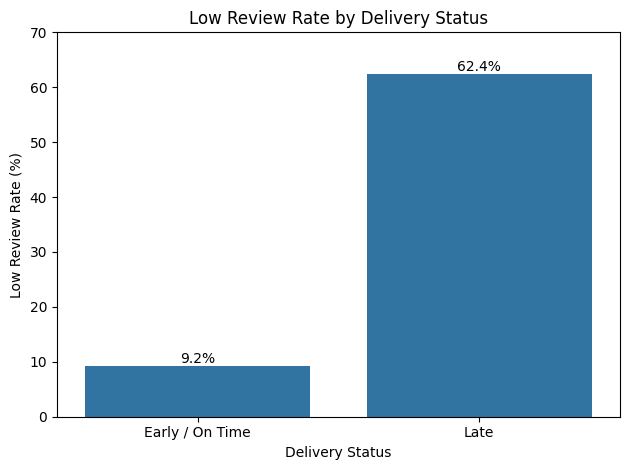

In [119]:
ax = sns.barplot(
    data=low_review_rate_delivery[
        low_review_rate_delivery["low_review"] == "Low Review"
    ],
    x="delivery_status",
    y="percentage"
)

plt.xlabel("Delivery Status")
plt.ylabel("Low Review Rate (%)")
plt.title("Low Review Rate by Delivery Status")
plt.ylim(0, 70)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.tight_layout()
plt.show()

### Visualization of Freight cost vs low-review rate

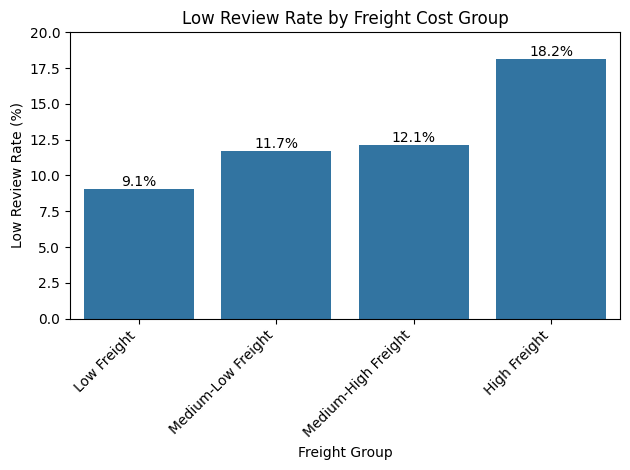

In [122]:
ax = sns.barplot(
    data=freight_low_review_analysis,
    x="freight_group",
    y="low_review_rate"
)

plt.xlabel("Freight Group")
plt.ylabel("Low Review Rate (%)")
plt.title("Low Review Rate by Freight Cost Group")
plt.ylim(0, 20)
plt.xticks(rotation=45,ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.tight_layout()
plt.show()

### Visualization of the relationship between Low reviews and delivery timing

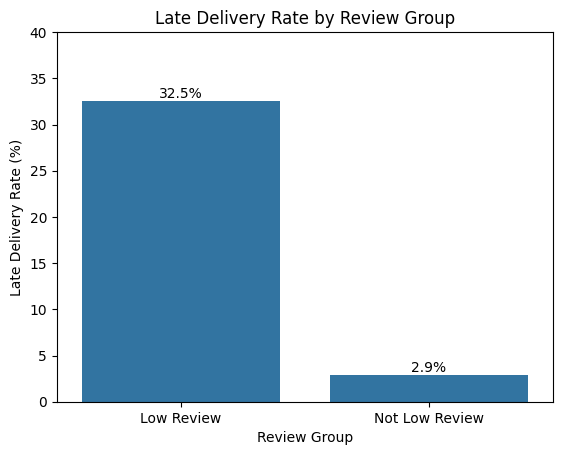

In [123]:
ax = sns.barplot(
    data=low_review_delivery[
        low_review_delivery["delivery_status"] == "Late"
    ],
    x="low_review",
    y="percentage"
)

plt.xlabel("Review Group")
plt.ylabel("Late Delivery Rate (%)")
plt.title("Late Delivery Rate by Review Group")
plt.ylim(0, 40)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Root-Cause analysis contributing factors:
1. **Delivery performance — strongest observed contributor**

* The evidence is particularly strong:

    * Late orders: 62.36% low-review rate
    * Early/on-time orders: 9.23% low-review rate
    * Low-review orders: 32.52% were late
    * Non-low-review orders: 2.87% were late
    * Delivery-delay correlation with review score: r = -0.267

  And the category analysis showed that the high low-review rate among late orders occurs across many categories rather than being restricted to one product category.

  ***Interpretation***: Delivery lateness is the strongest observed factor associated with poor reviews in this analysis.

2. **Freight cost — secondary contributor**
  * Low freight: 9.06% low reviews
  * High freight: 18.16% low reviews
  * Average review: 4.32 → 3.94

    But freight is also related to geography and delivery characteristics, so we shouldn't interpret it independently.

    ***Interpretation***: Higher freight is associated with poorer satisfaction, but its independent contribution isn't established.

3. **Geography — secondary contributor**

* Different-state orders:

    * Low-review rate: 14.09%
    * Same-state: 10.42%

* And different-state orders had:
    * Late rate: 7.89%
    * Same-state: 4.46%

  So geography appears relevant, but it may partly operate through transportation and delivery performance.

4. **Order value — secondary contributor**
    * Low-value orders: 10.34% low reviews
    * High-value orders: 15.86%
    * Average review: 4.24 → 4.05

    Again, this is an association rather than evidence that expensive purchases themselves cause dissatisfaction.

5. **Payment behavior — relatively weak contributor**

* Payment method averages were relatively close, roughly 3.95–4.17 among the meaningful groups.

* More importantly:

  Installment count vs review score: r = -0.031

  That's essentially a negligible linear relationship.

  Meanwhile, installments had a much stronger relationship with order value:

    * 1 installment: 121.04
    * 2–6: 155.45
    * 7+: 337.16

    So payment behavior appears much more relevant to purchase value than to customer satisfaction.

### Objective 5 Conclusion:
Delivery lateness was the strongest observed factor associated with low customer reviews in the Olist dataset. However, it was not the sole contributor: approximately two-thirds of low-review orders were still delivered early or on time. Higher freight costs, different-state shipping, and higher order values were also associated with higher low-review rates, while payment type and installment count showed relatively weak relationships with satisfaction. These findings indicate that poor reviews likely reflect multiple aspects of the customer experience rather than a single cause.